In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
# Step 1: Upload Trader CSV
from google.colab import files

print("📁 Please upload the FEAR & GREED INDEX CSV file (fear_greed_index.csv):")
uploaded_sentiment = files.upload()
sentiment_file = list(uploaded_sentiment.keys())[0]


📁 Please upload the FEAR & GREED INDEX CSV file (fear_greed_index.csv):


Saving fear_greed_index.csv to fear_greed_index.csv


In [ ]:
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
print(f"\nFear & Greed Index Data: {df_sentiment.shape[0]:,} rows × {df_sentiment.shape[1]} columns")
df_sentiment.head()


Fear & Greed Index Data: 2,644 rows × 4 columns


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
# Step 2: Data Cleaning

# Convert timestamp to datetime
if 'timestamp' in df_sentiment.columns:
    df_sentiment['date'] = pd.to_datetime(df_sentiment['timestamp'], unit='s').dt.date

# Rename columns for easier access
df_sentiment.rename(columns={'classification': 'Classification', 'value': 'Value'}, inplace=True)

# Check missing values
print("\nMissing Values per Column:")
print(df_sentiment.isnull().sum())


Missing Values per Column:
timestamp         0
Value             0
Classification    0
date              0
dtype: int64


In [ ]:
# Step 3: Descriptive Statistics
print("\n📊 Descriptive Statistics of Index Values:")
print(df_sentiment['Value'].describe())



📊 Descriptive Statistics of Index Values:
count    2644.000000
mean       46.981089
std        21.827680
min         5.000000
25%        28.000000
50%        46.000000
75%        66.000000
max        95.000000
Name: Value, dtype: float64


In [ ]:
# Additional statistics
print("\n Variance:", df_sentiment['Value'].var())
print(" Standard Deviation:", df_sentiment['Value'].std())
print(" Median:", df_sentiment['Value'].median())
print(" Min:", df_sentiment['Value'].min())
print(" Max:", df_sentiment['Value'].max())

# Distribution by Classification
print("\n Average Index Value per Classification:")
avg_value_class = df_sentiment.groupby('Classification')['Value'].mean()
print(avg_value_class)


 Variance: 476.4476180336499
 Standard Deviation: 21.827680088219406
 Median: 46.0
 Min: 5
 Max: 95

 Average Index Value per Classification:
Classification
Extreme Fear     18.273622
Extreme Greed    82.116564
Fear             34.184379
Greed            65.846761
Neutral          49.964646
Name: Value, dtype: float64


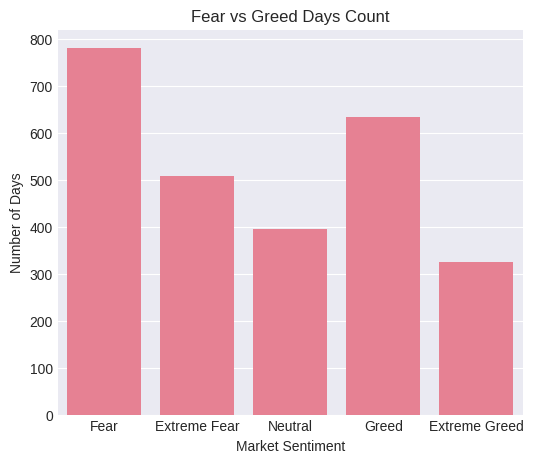

In [ ]:
# Step 4: Exploratory Data Analysis (EDA)
# 1️ Classification Distribution (Fear / Greed)
plt.figure(figsize=(6,5))
sns.countplot(x='Classification', data=df_sentiment)
plt.title("Fear vs Greed Days Count")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Days")
plt.show()

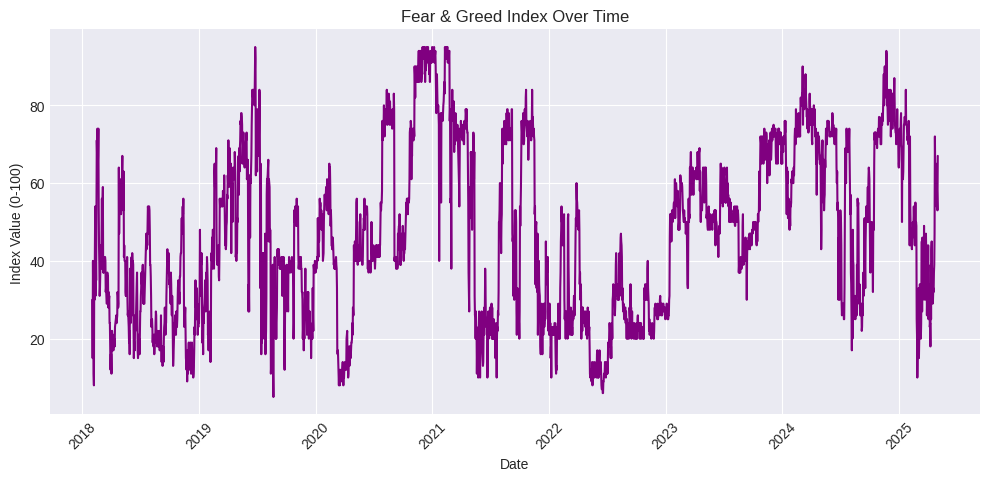

In [ ]:
# 2️ Sentiment Value over Time
plt.figure(figsize=(12,5))
plt.plot(df_sentiment['date'], df_sentiment['Value'], color='purple')
plt.title("Fear & Greed Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value (0-100)")
plt.xticks(rotation=45)
plt.show()

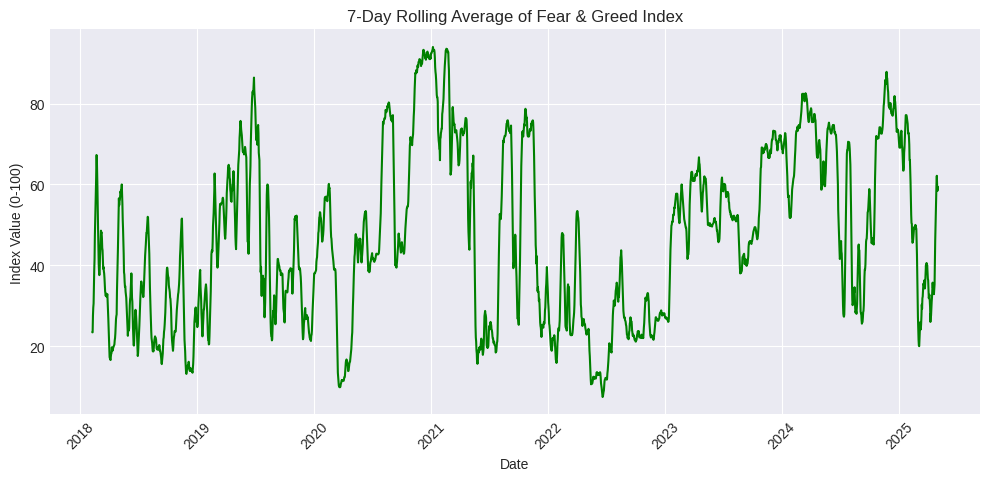

In [ ]:
# 3️ Rolling Average of Index (7-day)
df_sentiment['Value_Rolling7'] = df_sentiment['Value'].rolling(7).mean()
plt.figure(figsize=(12,5))
plt.plot(df_sentiment['date'], df_sentiment['Value_Rolling7'], color='green')
plt.title("7-Day Rolling Average of Fear & Greed Index")
plt.xlabel("Date")
plt.ylabel("Index Value (0-100)")
plt.xticks(rotation=45)
plt.show()

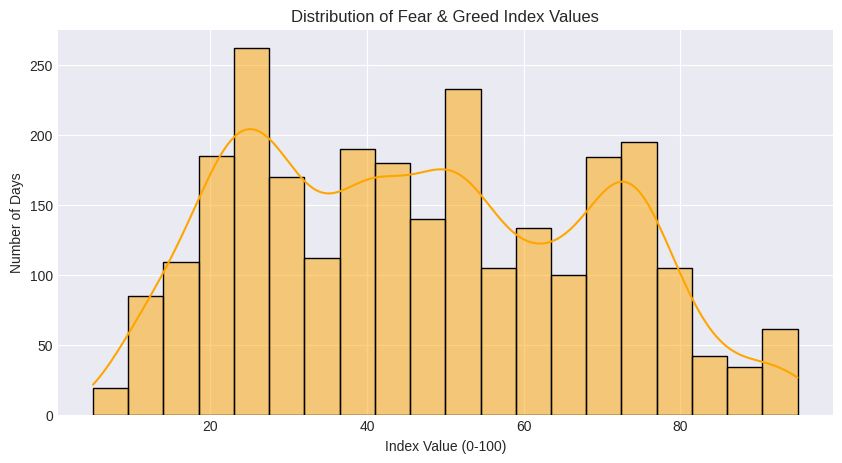

In [ ]:
# 4️ Histogram of Index Values
plt.figure(figsize=(10,5))
sns.histplot(df_sentiment['Value'], bins=20, kde=True, color='orange')
plt.title("Distribution of Fear & Greed Index Values")
plt.xlabel("Index Value (0-100)")
plt.ylabel("Number of Days")
plt.show()

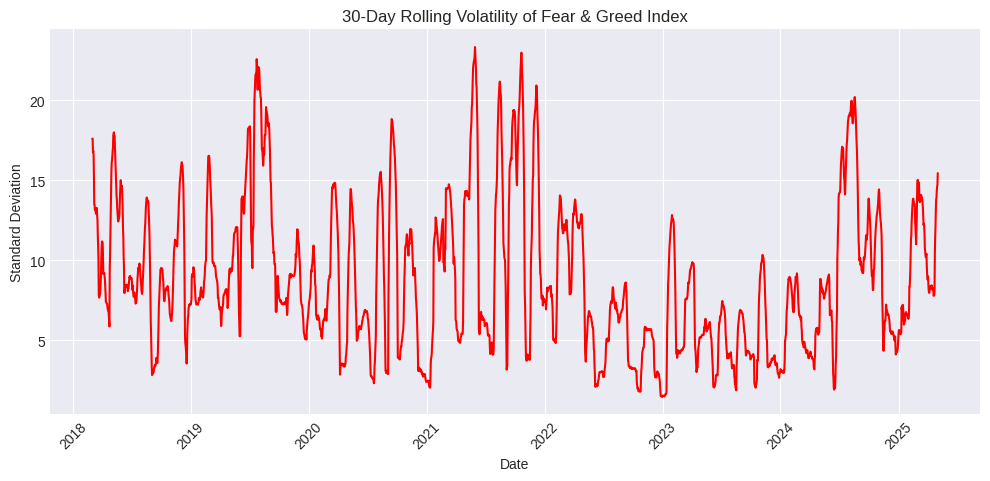

In [ ]:
#  6. Volatility (rolling 30-day std)
df_sentiment['Volatility_30'] = df_sentiment['Value'].rolling(30).std()
plt.figure(figsize=(12,5))
plt.plot(df_sentiment['date'], df_sentiment['Volatility_30'], color='red')
plt.title("30-Day Rolling Volatility of Fear & Greed Index")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 7. Correlation between Index Value & Rolling Avg
correlation = df_sentiment[['Value','Value_Rolling7']].corr().iloc[0,1]
print(f"\nCorrelation between Value and 7-day Rolling Average: {correlation:.2f}")



Correlation between Value and 7-day Rolling Average: 0.95


In [ ]:
# 8. Count of Extreme Fear/Greed Days
extreme_fear = df_sentiment[df_sentiment['Value']<=20].shape[0]
extreme_greed = df_sentiment[df_sentiment['Value']>=80].shape[0]
print(f"\nExtreme Fear Days (<=20): {extreme_fear}")
print(f"Extreme Greed Days (>=80): {extreme_greed}")


Extreme Fear Days (<=20): 298
Extreme Greed Days (>=80): 165


In [ ]:
# Create outputs folder if not exists
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Save cleaned data
df_sentiment.to_csv('outputs/fear_greed_index_cleaned.csv', index=False)
print("\n Notebook 2 Completed. All charts saved in 'outputs/' and cleaned CSV saved.")


 Notebook 2 Completed. All charts saved in 'outputs/' and cleaned CSV saved.
